In [70]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [71]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operator: str
    result: int


In [72]:
def adder(state: AgentState) -> AgentState:
    """
    This node add two numbers
    """

    state["result"] = state["number1"] + state["number2"]

    return state

def substractor (state: AgentState) -> AgentState:
    """
    This node substract two numbers
    """

    state["result"] = state["number1"] - state["number2"]

    return state

def decide_next_node(state: AgentState) -> AgentState:
    """
    This function decide wich operation to execute
    """
    if state["operator"] == '+':
        return "addition_operation"
    elif state["operator"] == '-':
        return "substraction_operation"

 

In [73]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("substractor",substractor)
graph.add_node("router",lambda state:state )


graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "adder",
        "substraction_operation": "substractor"
    }
    )

graph.add_edge("adder",END)
graph.add_edge("substractor",END)

app = graph.compile()

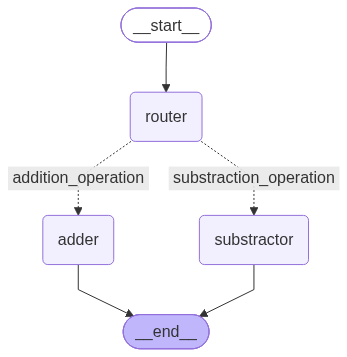

In [74]:

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [75]:
initial_state_1 = AgentState(number1 = 10, operator='+', number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'number2': 5, 'operator': '+', 'result': 15}


In [76]:
# This way still works!

result = app.invoke({"number1": 10, "operator": '-', "number2": 5})
print(result)

{'number1': 10, 'number2': 5, 'operator': '-', 'result': 5}
